# Keyword Spotting (KWS) TinyML Application
**Keyword spotting (KWS)** is a specialized subfield of speech recognition technology that focuses on detecting specific, predefined words or phrases within a continuous stream of audio. Unlike full automatic speech recognition systems, which transcribe every word spoken, KWS ignores all background chatter and unrelated audio, reacting only when it identifies its target triggers (i.e., wakeword). A **wake word** is a predefined spoken phrase that triggers a voice-activated device to transition from passive listening to active engagement. It acts as a digital name for your smart assistant, signaling that the command immediately following it is meant for the system. Saying "*Hey Siri*", "*Alexa*", or "*OK Google*" to activate your smart devices.

This notebook covers the end-to-end process of preparing data, training a model, and exporting it to C for deployment on the Arduino Nano 33 BLE Sense using `emlearn`. The onboard microphone captures PDM audio, extracts "**Mel-Frequency Cepstral Coefficients** (MFCC)", and uses a neural network to detect specific trigger words.

## Read Dataset Audio Files from Zip Files
You can use the Python **zipfile** module to read audio files from a dataset without fully extracting them to your hard drive. This approach is ideal for large datasets because it saves disk space and minimizes I/O. The following approach identifies audio files within a ZIP, extracts metadata (like filename and label), and stores this information in a DataFrame.

In [1]:
from pathlib import Path
import zipfile
import pandas as pd

# Dataset root used by later cells
dataset_folder = Path("dataset")
target_labels = {"jarvis", "noise", "negative"}

# Discover zip archives and map label from the zip filename stem
zip_files = sorted(dataset_folder.glob("*.zip"))
if not zip_files:
    raise FileNotFoundError(
        f"No .zip files found in {dataset_folder.resolve()}. "
        "Expected archives such as jarvis.zip, noise.zip, and negative.zip."
    )

# Extract audio file paths and labels from zip archives
records = []
for zip_path in zip_files:
    label = zip_path.stem.lower()
    if label not in target_labels:
        continue

    with zipfile.ZipFile(zip_path, "r") as zf:
        for member in zf.namelist():
            if member.endswith("/"):
                continue
            if Path(member).suffix.lower() in {".wav", ".flac", ".mp3", ".ogg", ".m4a"}:
                records.append(
                    {
                        "label": label,
                        "audio_file": member,
                        "zip_file": zip_path.name,
                        "zip_path": str(zip_path),
                    }
                )

# Create DataFrame and validate content
audio_df = pd.DataFrame(records)
if audio_df.empty:
    raise ValueError(
        "No audio files were found inside jarvis/noise zip archives. "
        "Verify archive content and file extensions."
    )

# Keep reproducible ordering for training/evaluation splits
audio_df = audio_df.sort_values(["label", "audio_file"]).reset_index(drop=True)

# Check for missing expected labels
missing_labels = sorted(target_labels - set(audio_df["label"].unique()))
if missing_labels:
    print(f"Warning: missing expected labels in zips: {missing_labels}")

# Display summary and sample of the dataset
print(f"Found {len(audio_df)} audio files across labels: {sorted(audio_df['label'].unique())}")

# Show a sample of the dataset without the index column for cleaner display
audio_df.sample(10).style.hide(axis='index')

Found 5000 audio files across labels: ['jarvis', 'negative', 'noise']


label,audio_file,zip_file,zip_path
negative,negative/up_772.wav,negative.zip,dataset\negative.zip
jarvis,jarvis/Okay_Jarvis_78.wav,jarvis.zip,dataset\jarvis.zip
negative,negative/stop_2531.wav,negative.zip,dataset\negative.zip
negative,negative/off_2341.wav,negative.zip,dataset\negative.zip
jarvis,jarvis/Okay_Jarvis_114.wav,jarvis.zip,dataset\jarvis.zip
noise,noise/synthetic_459.wav,noise.zip,dataset\noise.zip
negative,negative/right_1763.wav,negative.zip,dataset\negative.zip
negative,negative/up_670.wav,negative.zip,dataset\negative.zip
negative,negative/left_1435.wav,negative.zip,dataset\negative.zip
jarvis,jarvis/Jarvis_wake_up_135.wav,jarvis.zip,dataset\jarvis.zip


## Visualizing Audio Signal in Time Domain
Plotting audio signals in the time domain allows you to visualize how the amplitude of an audio wave changes over time. You can easily do this in Python using Matplotlib for plotting and Librosa to load the audio files. **Librosa** is a popular open-source Python package specifically designed for music and audio analysis. It provides the building blocks for creating music information retrieval systems, making it a standard tool for researchers and developers in audio signal processing and machine learning.

Librosa is built on top of high-performance libraries like NumPy and SciPy, and it often uses Matplotlib for visualization. Its primary capabilities includes:
* **Audio Loading & Preprocessing**: Load audio files (WAV, MP3, OGG, FLAC, etc.) as floating-point time series and automatically resample them to a target rate.
* **Feature Extraction**: Extract critical audio features such as Mel Spectrograms, MFCCs (Mel-frequency cepstral coefficients), Chroma features, and Spectral Centroids.
* **Temporal Analysis**: Perform beat tracking, tempo estimation, and onset detection.
* **Signal Processing**: High-quality pitch shifting, time stretching, and harmonic-percussive source separation (HPSS).
* **Visualization**: Integrated tools to display waveforms and spectrograms using librosa.display.

You can install the latest stable version of Librosa using:
```bash
pip install librosa
```
A discrete-time audio signal represents sound as a sequence of distinct numerical values, sampled from a continuous (analog) microphone waveform. The most fundamental equation for a discrete-time signal, $x[n]$, obtained by sampling an analog signal $x_{a}(t)$ with a sampling period $T_{s}$ (where $T_s = \frac{1}{f_s}$), is:

$$
x[n] = x_{a}(nT_s)
$$

Where:
* $n$: The sample index (an integer: $0, 1, 2, \dots$) indicating the discrete moment in time.
* $x[n]$: The amplitude of the audio signal at sample step $n$.
* $f_{s}$: The sampling frequency. is the number of distinct measurements or "snapshots" taken per second to convert a continuous analog signal into a discrete digital signal. Measured in $\text{Hertz}$ ($Hz$) or samples per second, it dictates the resolution and accuracy of digital data. For example, standard voice audio is sampled at $f_s = 16,000 \text{ Hz}$.
* $T_{s}$: The sampling interval. Refers to the specific time duration, distance, or sequence step between consecutive measurements of a signal. The sampling interval is the inverse of the sampling frequency $f_{s}$.

## Visualizing Audio Signal in Frequency Domain
Visualizing an audio signal in the frequency domain means decomposing a complex sound wave into its individual sinusoidal frequencies and plotting their respective amplitudes. While a standard time-domain waveform shows how "*sound amplitude*" changes over time, a frequency-domain view reveals the exact "*frequency content*" of that sound at a single moment.

A **spectrogram** is a visual representation of how the frequency content of an audio signal changes over time. It converts a standard 1D sound waveform into a 2D map where the x-axis is time, the y-axis is frequency, and the color intensity represents amplitude or loudness.

### How a Spectrogram Works
To capture both when a sound happens and what its frequencies are, the signal is broken into small chunks.
* **Windowing**: The audio is divided into overlapping segments (e.g., 20-30 milliseconds) to isolate small moments in time.
* **FFT (Fast Fourier Transform)**: Each segment is run through the FFT algorithm, which breaks down the complex audio wave into individual frequency components and their volumes.
* **Mapping**: The resulting frequency spectrums are stacked sequentially and color-mapped, creating the final 2D image.

In other words, the **Short-Time Fourier Transform (STFT)** is a powerful signal processing technique used to analyze how the frequency content of a non-stationary signal changes over time. While a standard Fourier Transform (FT) breaks a signal down into its component frequencies, it loses all information about when those frequencies occurred. STFT solves this limitation by segmenting the signal into short, localized time intervals and computing the Fourier Transform for each section individually.

$$
X(m, \omega) = \sum_{n=-\infty}^{\infty} x[n] \cdot w[n - mR] \cdot e^{-j\omega n}
$$

Where:
* $x[n]$: The input discrete-time audio signal.
* $w[n]$: The window function (e.g., Hamming or Hann) that isolates a segment of the signal.
* $m$: The time index (or frame index).
* $R$: The hop size (or shift), representing the number of samples the window moves between frames.
* $k$: The frequency bin index.
* $N$: The size of the FFT/window length.

Visualizing an audio signal in the frequency domain is typically done by generating a spectrogram using the Short-Time Fourier Transform (STFT). It maps how frequencies change over time. In Python, you can use the Librosa library alongside Matplotlib for plotting.

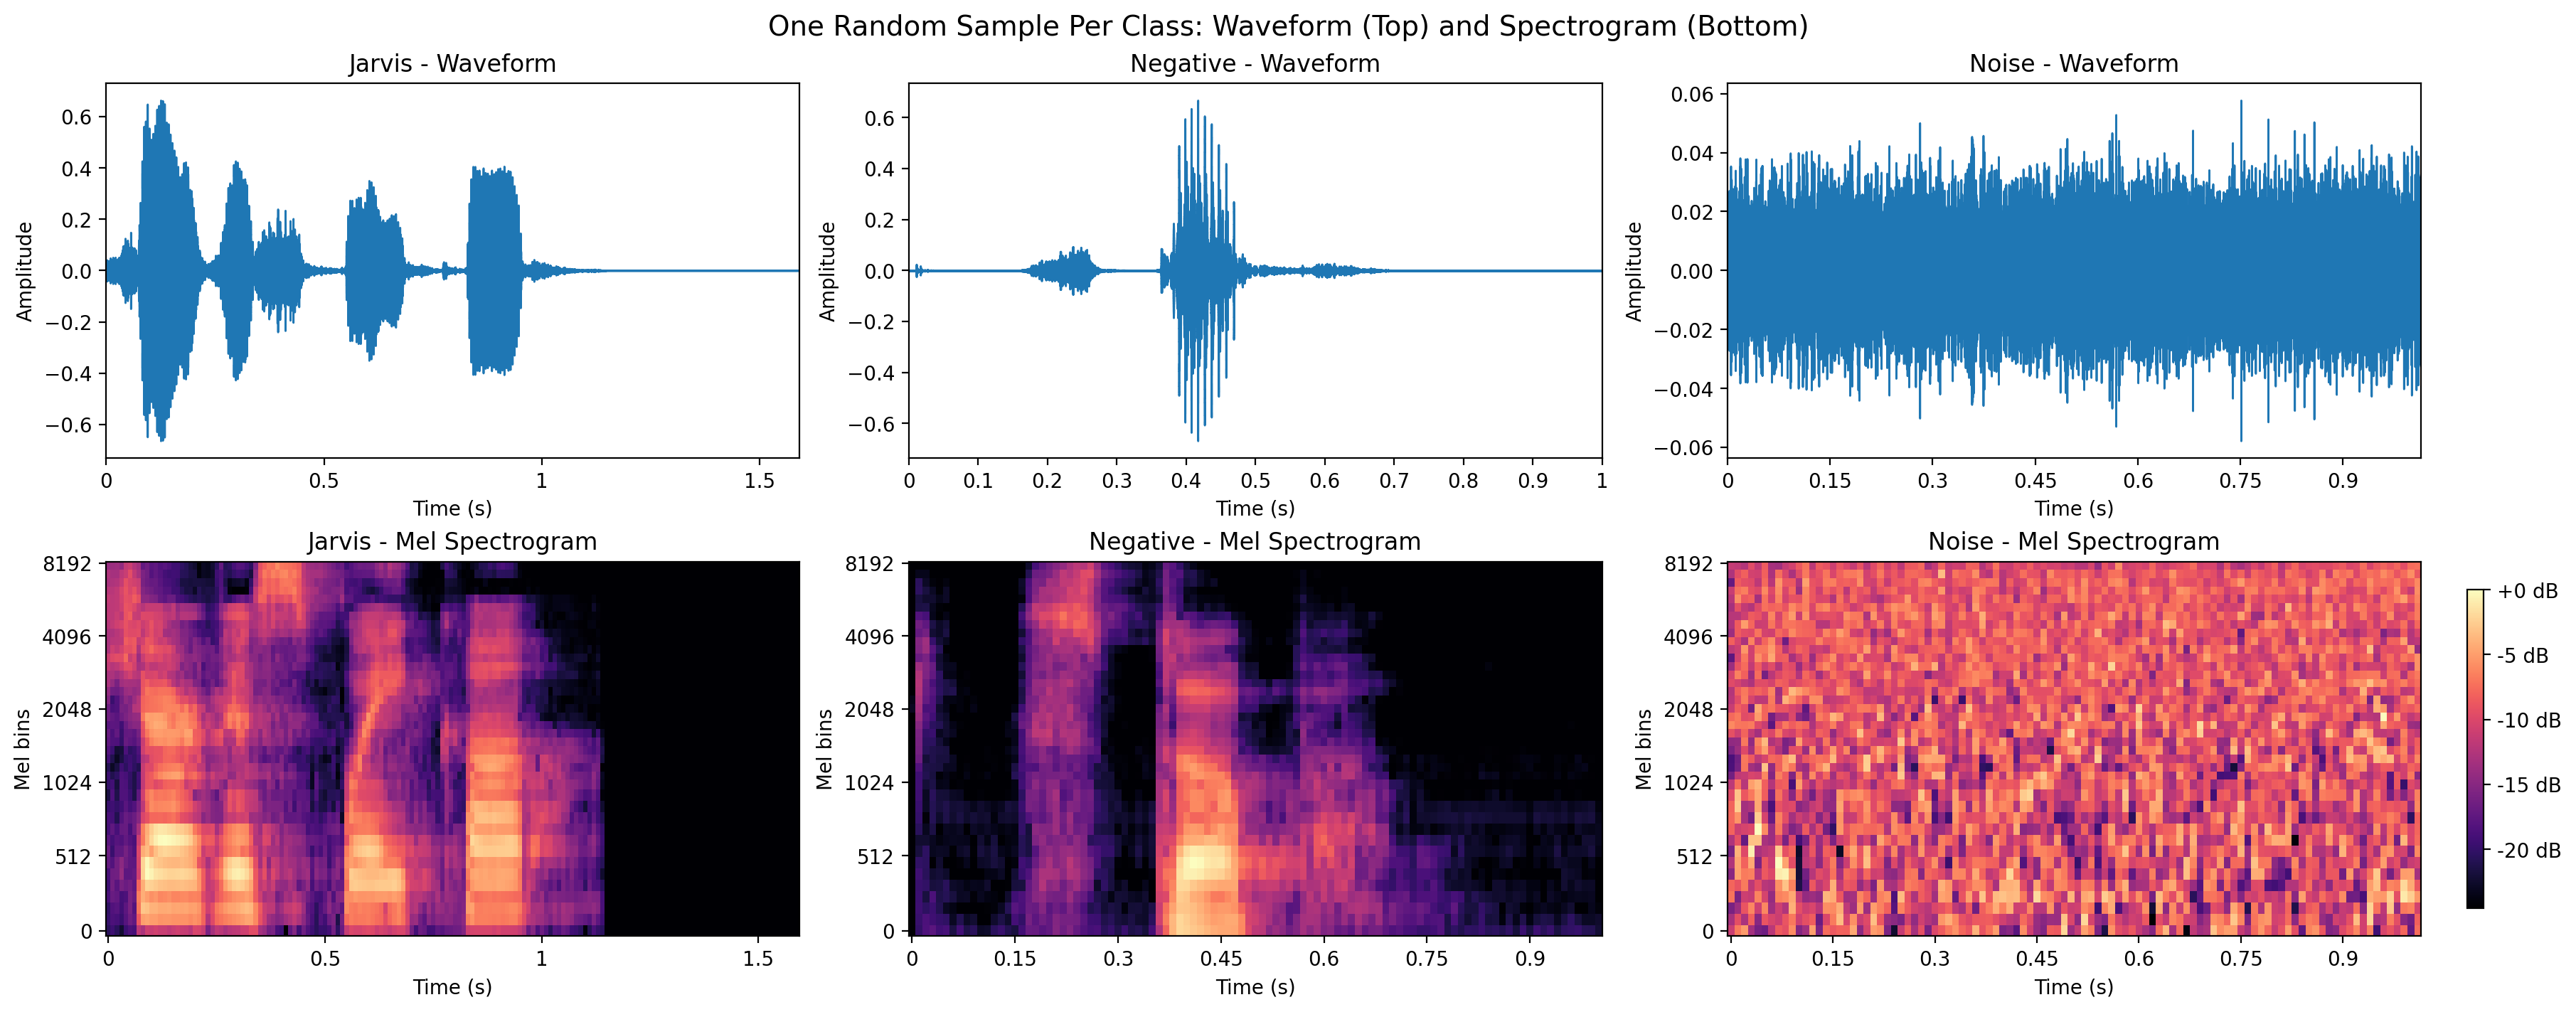

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Keep mel parameters aligned with downstream feature extraction cells
mel_params = {
    'sample_rate': 16000,  # Resample to 16 kHz
    'n_mels': 40,          # Compact mel feature size
    'fmin': 20,            # Ignore near-DC rumble
    'fmax': 8000,          # Speech-relevant upper band
    'n_fft': 256,          # FFT size
    'hop_length': 160,     # 10 ms hop at 16 kHz
    'win_length': 256,     # 16 ms window at 16 kHz
    'window': 'hann',      # Match Arduino-side windowing intent
    'power': 2.0,          # Power spectrogram
}

# Pick one random sample per class (noise, jarvis).
# Leave seed=None for a different sample each run.
# Set seed to an integer (for example 42) if you want reproducible plots.
seed = None
samples_per_class = (
    audio_df.groupby('label', group_keys=False)
    .sample(n=1, random_state=seed)
    .sort_values('label')
    .reset_index(drop=True)
)

n_classes = len(samples_per_class)
fig, axes = plt.subplots(
    2, n_classes, figsize=(6 * n_classes, 7), dpi=200, squeeze=False, constrained_layout=True
)

for col, row in enumerate(samples_per_class.itertuples(index=False)):
    label = row.label
    audio_file = row.audio_file

    # Prefer explicit zip_path from dataframe; fallback to dataset_folder/zip_file
    zpath = Path(row.zip_path) if hasattr(row, 'zip_path') else (dataset_folder / row.zip_file)
    if not zpath.exists():
        zpath = dataset_folder / row.zip_file

    with zipfile.ZipFile(zpath, 'r') as zip_ref:
        with zip_ref.open(audio_file) as audio_f:
            y, sr = librosa.load(audio_f, sr=mel_params['sample_rate'])

    # Top row: waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0, col])
    axes[0, col].set_title(f"{label.capitalize()} - Waveform")
    axes[0, col].set_xlabel('Time (s)')
    axes[0, col].set_ylabel('Amplitude')
    axes[0, col].set_xlim(0, librosa.get_duration(y=y, sr=sr))

    # Bottom row: mel spectrogram
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=mel_params['n_mels'],
        fmin=mel_params['fmin'],
        fmax=mel_params['fmax'],
        n_fft=mel_params['n_fft'],
        hop_length=mel_params['hop_length'],
        win_length=mel_params['win_length'],
        window=mel_params['window'],
        power=mel_params['power'],
    )
    S_dB = librosa.power_to_db(S, ref=np.max, top_db=80)

    img = librosa.display.specshow(
        S_dB,
        sr=sr,
        hop_length=mel_params['hop_length'],
        x_axis='time',
        y_axis='mel',
        ax=axes[1, col],
    )
    axes[1, col].set_title(f"{label.capitalize()} - Mel Spectrogram")
    axes[1, col].set_xlabel('Time (s)')
    axes[1, col].set_ylabel('Mel bins')

# Shared colorbar for all spectrograms
fig.colorbar(img, ax=axes[1, :].tolist(), format='%+2.0f dB', shrink=0.85, pad=0.02)
fig.suptitle('One Random Sample Per Class: Waveform (Top) and Spectrogram (Bottom)', fontsize=14)
plt.show()

## Play Audio Samples
You can play audio samples in environment frontends like Jupyter Notebook or Google Colab using ```IPython.display.Audio```. You may play sounds from local files, web URLs, or directly generated NumPy arrays. To play a loaded audio sample in a Jupyter Notebook using ```IPython.display.Audio```, you pass the loaded NumPy array data and its corresponding sample rate directly into the ```Audio``` class.

In [3]:
from IPython.display import Audio

# Load the 3 random audio samples for playback
audio_samples = []
for row in samples_per_class.itertuples(index=False):
    label = row.label
    audio_file = row.audio_file

    # Prefer explicit zip_path from dataframe; fallback to dataset_folder/zip_file
    zpath = Path(row.zip_path) if hasattr(row, 'zip_path') else (dataset_folder / row.zip_file)
    if not zpath.exists():
        zpath = dataset_folder / row.zip_file

    # Extract audio data from the zip file for the selected sample
    with zipfile.ZipFile(zpath, 'r') as zip_ref:
        with zip_ref.open(audio_file) as audio_f:
            # Load audio data using librosa for playback
            y, sr = librosa.load(audio_f, sr=mel_params['sample_rate'])
            
            # Store the label, audio data, and sample rate for later playback
            audio_samples.append((label, y, sr))
            
# Display audio players for the samples
for label, y, sr in audio_samples:
    print(f"Label: {label.capitalize()}")
    display(Audio(y, rate=sr))

Label: Jarvis


Label: Negative


Label: Noise


## Speech Processing for Machine Learning: Mel Filterbanks and Log-Mel Spectrograms

A **mel filterbank** is an audio processing tool that transforms standard, linear sound frequencies into a scale that mimics how the human ear perceives pitch. It converts linear frequency bins (Hz) into perceptually equal pitch distances (Mels). converts linear frequency bins (Hz) into perceptually equal pitch distances (Mels). To do this, overlapping triangular filters are applied across the spectrum to extract and smooth the energy. Each mel filter is a triangular bandpass window centered on a mel-spaced frequency, and adjacent filters overlap so that nearby spectral energy is shared smoothly across bands.

Humans perceive pitches logarithmically. We are highly sensitive to small changes in low frequencies but much less sensitive to changes at higher frequencies. Thus, mel scale is commonly written as:

$$
m = 2595 \log_{10}\left(1 + \frac{f}{700}\right)
$$

where $f$ is frequency in Hertz and $m$ is the corresponding mel value.

The inverse mapping from mel back to Hertz is:

$$
f = 700\left(10^{m/2595} - 1\right)
$$

When designing a Mel filterbank, the goal is to map linear audio frequencies to a perceptually relevant, non-linear scale that mimics human pitch perception. You compress the frequency resolution in higher bands to reflect human hearing. Key design parameters and trade-offs must be evaluated.

### Fundamental Parameters
* Number of Mel Filters $N_{mels}$: Dictates the resolution of the resulting Mel spectrogram.
* Frequency Boundaries ($F_{min}$ and $F_{max}$):
    * $F_{min}$: is often set to $0$ Hz, though typical voice processing might set it slightly higher (e.g., $64$ Hz or $300$ Hz) to filter out low-frequency noise.
    * $F_{max}$: should theoretically match the Nyquist frequency. However, limiting it to $8000$ Hz ($F_{s}/2$) is standard, as most human speech information resides below this limit.
* Filter Shape & Overlap: Filters are typically triangular and overlap by $50%$. The center frequency of one filter coincides with the start/end points of the adjacent filters.

In [4]:
import emlearn.signal

# Generate a standard Librosa Mel filterbank
mel_filterbank = librosa.filters.mel(
    sr=mel_params['sample_rate'],   # Sampling rate
    n_fft=mel_params['n_fft'],      # FFT size
    n_mels=mel_params['n_mels'],    # Number of mel bands
    fmin=mel_params['fmin'],        # Minimum frequency
    fmax=mel_params['fmax'],        # Maximum frequency
)

# Target the emlearn sparse representation
sparse_filterbank = emlearn.signal.sparse_filterbank(mel_filterbank)

# We extract frequencies explicitly to map bins correctly
mel_frequencies = librosa.fft_frequencies(sr=mel_params['sample_rate'], n_fft=mel_params['n_fft'])

# Generate the C Header file string for the sparse filterbank
mel_filterbank_c_code = emlearn.signal.sparse_filterbank_serialize(
    sparse_filterbank,
    name="mel_filterbank",
    frequencies=mel_frequencies,
    n_fft=mel_params['n_fft'],
    sr=mel_params['sample_rate'],
    fmax=mel_params['fmax'],
    fmin=mel_params['fmin']
)

# Print the generated C header code
print(mel_filterbank_c_code)

# Save the C header code to a file
with open("mel_filterbank.h", "w") as f:
    f.write(mel_filterbank_c_code)

static const int mel_filterbank_bands = 40; 

static const int mel_filterbank_starts[40] = { 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 19, 20, 21, 23, 25, 27, 29, 31, 33, 36, 39, 42, 45, 49, 52, 56, 61, 65, 71, 76, 82, 88, 95, 103, 111 };

static const int mel_filterbank_ends[40] = { 2, 3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 20, 22, 24, 26, 28, 30, 32, 35, 38, 41, 44, 48, 51, 55, 60, 64, 70, 75, 81, 87, 94, 102, 110, 118, 127 };

static const int mel_filterbank_length = 244; 

static const float mel_filterbank_lut[244] = { 0.007957f, 0.007707f, 0.005976f, 0.009689f, 0.003995f, 0.011670f, 0.002013f, 0.013651f, 0.001949f, 0.000032f, 0.011734f, 0.003931f, 0.009752f, 0.005912f, 0.007771f, 0.007893f, 0.005790f, 0.009875f, 0.003808f, 0.011856f, 0.000154f, 0.001827f, 0.013529f, 0.002135f, 0.011548f, 0.004117f, 0.009566f, 0.006098f, 0.007465f, 0.008124f, 0.005045f, 0.010076f, 0.000365f, 0.002441f, 0.011420f, 0.003744f, 0.007432f, 0.006963f, 0.003656f, 0.009941f, 0.003781f,


A **Mel filterbank** consists of a series of overlapping triangular filters spaced along the Mel scale. Filters are tightly packed together at lower frequencies and become progressively wider and farther apart at higher frequencies. When applied to a sound wave's frequency spectrum, each triangle collects and sums the energy within its specific band, reducing the overall number of data points while keeping the features that matter most to human hearing.

For filter index $i$, the triangular mel filter $H_i(k)$ over frequency bin $k$ can be written as:

$$
H_i(k) =
\begin{cases}
0, & k < f_{i-1} \\[4pt]
\dfrac{k - f_{i-1}}{f_i - f_{i-1}}, & f_{i-1} \le k \le f_i \\[8pt]
\dfrac{f_{i+1} - k}{f_{i+1} - f_i}, & f_i \le k \le f_{i+1} \\[8pt]
0, & k > f_{i+1}
\end{cases}
$$

where $f_{i-1}$, $f_i$, and $f_{i+1}$ are the left edge, center, and right edge of the triangular filter, respectively.

After defining the filters, the energy $E(m)$ for each Mel bin is calculated by multiplying the magnitude spectrum $X(k)$ by the filter $H_m(k)$ and summing them up:
$$
E(m)=\sum_{K=0}^{N-1}\left | X(k)\right |^2H_{m}(k)
$$

Standard frequency scales (like those from a Fourier Transform) treat every frequency equally, producing too much redundant data. By passing the audio through a mel filterbank, the data size is compressed and adapted to match human auditory perception. This makes it significantly easier for machine learning and AI models to process audio. This structure compresses the spectrum while preserving the speech-relevant shape of the audio energy distribution. It is the basis for both log-mel spectrograms and MFCC feature extraction. 

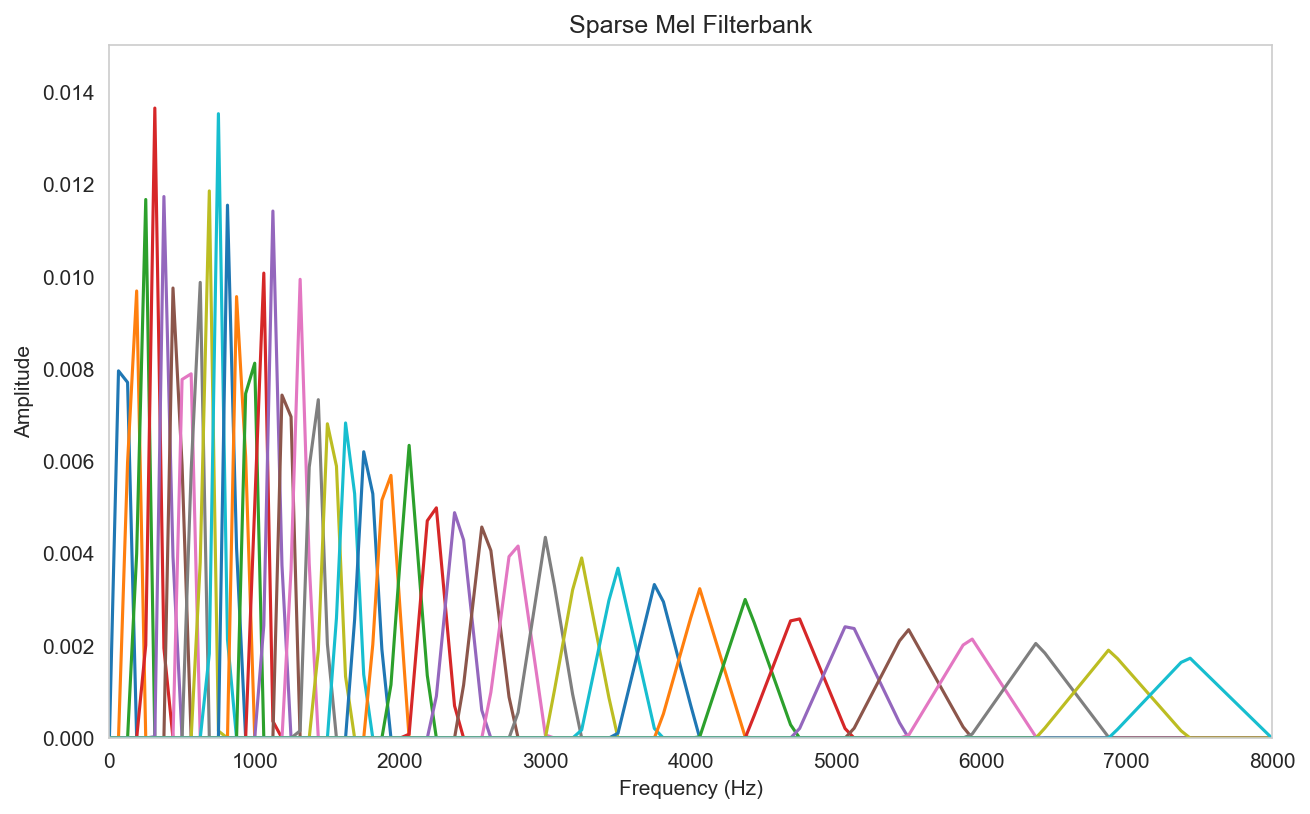

In [5]:
import seaborn as sns

# Visualize the original dense mel filterbank for reference
plt.figure(figsize=(10, 6), dpi=150)

# Use seaborn for a cleaner line plot style
sns.set_style("whitegrid")

# Iterate over each filter in the original mel filterbank and plot it
for i in range(mel_filterbank.shape[0]):
    # Plot the original dense filterbank using seaborn's lineplot 
    sns.lineplot(x=mel_frequencies, y=mel_filterbank[i], linewidth=1.5)

# Set the title and labels for the plot
plt.title('Sparse Mel Filterbank')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, mel_params['sample_rate'] / 2)
plt.ylim(0, np.max(mel_filterbank) * 1.1)
plt.grid()  
plt.show()

## Learnable Sparse Filterbank Audio Processing
A **sparse Mel filterbank** compression pipeline is an efficient audio processing architecture used to compress dense spectrogram representations into compact, perceptually relevant features. By mapping linear frequencies to the Mel scale and enforcing sparsity, it drastically reduces model sizes and computational load for edge devices and AI models.

### The Pipeline Breakdown
1. The raw audio waveform is converted into a linear-scale time-frequency representation, usually via a **Short-Time Fourier Transform** (STFT) or a learnable time-domain frontend.
2. Compute the Fast Fourier Transform (FFT) of each windowed frame. Square the absolute values of the coefficients to get the **power spectrum**, representing signal energy per frequency bin.
3. The **power spectrum is multiplied by a sparse Mel filterbank matrix**. This matrix consists of overlapping triangular filters that compress the dense frequency bins into a smaller number of Mel bands (e.g., 40, 80, or 128).
4.  Calculate the **natural logarithm** or **decibel equivalent** of the Mel-band energies. This simulates the logarithmic response of human loudness perception and compresses the feature's dynamic range.

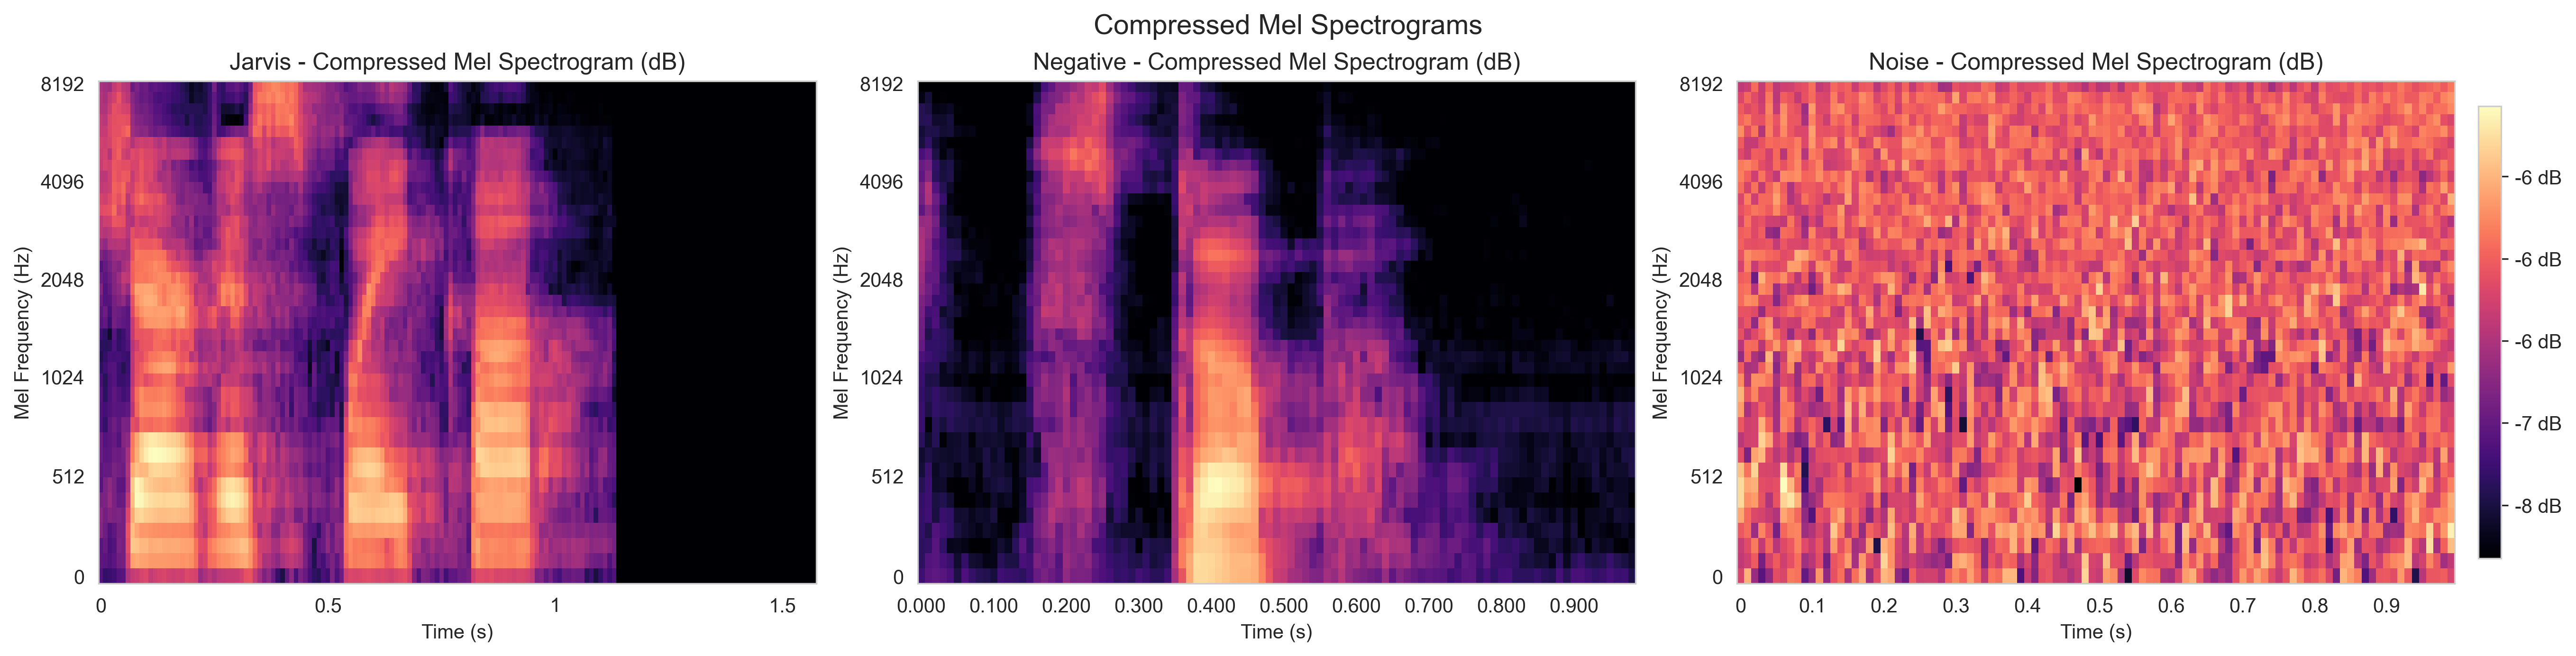

In [6]:
# Determine the number of classes for subplot arrangement
n_classes = len(samples_per_class)
fig, axes = plt.subplots(
    1, n_classes, figsize=(6 * n_classes, 4.5), dpi=300, squeeze=False, constrained_layout=True
)
axes = axes.ravel()

# Apply Sparse Mel Filterbank to the selected random audio samples and plot the resulting features
for col, row in enumerate(samples_per_class.itertuples(index=False)):
    label = row.label
    audio_file = row.audio_file

    # Prefer explicit zip_path from dataframe; fallback to dataset_folder/zip_file
    zpath = Path(row.zip_path) if hasattr(row, 'zip_path') else (dataset_folder / row.zip_file)
    if not zpath.exists():
        zpath = dataset_folder / row.zip_file

    with zipfile.ZipFile(zpath, 'r') as zip_ref:
        with zip_ref.open(audio_file) as audio_f:
            y, sr = librosa.load(audio_f, sr=mel_params['sample_rate'])

    # 1. Compute the STFT of the audio signal using the same parameters as the mel spectrogram
    stft = librosa.stft(
        y,
        n_fft=mel_params['n_fft'],
        hop_length=mel_params['hop_length'],
        win_length=mel_params['win_length'],
        window=mel_params['window'],
        center=False,
        dtype=np.complex64,
    )
    
    # 2. Compute the power spectrogram and normalize by the number of FFT points
    local_pwrspectrum = (np.abs(stft) ** 2) / mel_params['n_fft']

    # 3. Compute for the mel features using emlearn's sparse filterbank reduce
    # emlearn.sparse_filterbank_reduce expects a 1D spectrum, so reduce per frame
    mel_comp = np.stack([
        emlearn.signal.sparse_filterbank_reduce(
            sparse_filterbank, local_pwrspectrum[:, frame].astype(np.float32, copy=False)
        )
        for frame in range(local_pwrspectrum.shape[1])
    ], axis=1).astype(np.float32)

    # 4. Compute the compressed mel spectrogram in dB using log10(max(x, 1e-10))
    mel_db = np.log10(np.maximum(mel_comp, np.float32(1e-10))).astype(np.float32)

    # Display the compressed mel spectrogram
    img_mel = librosa.display.specshow(
        mel_db,
        sr=sr,
        hop_length=mel_params['hop_length'],
        x_axis='time',
        y_axis='mel',
        ax=axes[col],
    )
    
    # Set the title and labels for the subplot
    axes[col].set_title(f"{label.capitalize()} - Compressed Mel Spectrogram (dB)")
    axes[col].set_xlabel('Time (s)')
    axes[col].set_ylabel('Mel Frequency (Hz)')

# Shared colorbar for all spectrograms
fig.colorbar(img_mel, ax=axes.tolist(), format='%+2.0f dB', shrink=0.9, pad=0.01)
fig.suptitle('Compressed Mel Spectrograms', fontsize=14)
plt.show()

In audio processing, a **Mel filterbank spectrogram** (Mel spectrogram) compresses a standard linear spectrogram in two (2) ways: 
1. frequency compression via a filterbank
```python
# 1. Frequency Compression: Apply Mel Filterbank
mel_spectrogram = librosa.feature.melspectrogram(S=S, sr=sr, n_mels=128)

# Or compute for the mel features using emlearn's sparse filterbank reduce
mel_spectrogram = np.stack([emlearn.signal.sparse_filterbank_reduce(...)])
```
2. magnitude compression usually via a decibel conversion.
```python
# 2. Magnitude Compression: Convert Power to Decibel (dB)
log_mel_spectrogram = librosa.power_to_db(mel_spectrogram)
```

Together, they transform audio data to mimic human auditory perception. A standard spectrogram measures frequencies on a strictly linear scale. However, the human ear perceives pitch logarithmically. After passing the signal through the Mel filterbank, the power/amplitude values are converted to the decibel (dB) scale using a logarithmic function. This compresses the dynamic range of the spectrogram, ensuring that the visual brightness of the image aligns with what humans actually hear. It also makes the data distribution more stable and manageable for machine learning models.

## Apply Sliding Window
Applying a sliding window is a fundamental technique in digital audio processing used to chunk long, continuous sound recordings into smaller, uniform segments or frames. This allows for feature extraction like Mel filterbank, MFCCs or Spectrograms, prior to model training. 

The raw audio data is segmented into overlapping frames as follows.
- **Window Size**: 1000ms
- **Window Stride**: 250ms
- **Window Function**: boxcar

In [7]:
from scipy.signal import get_window

# Build a window function for framing the signal
def build_window(window_type='boxcar', length=8, symmetric=False):
    fftbins = not symmetric
    return get_window(window_type, length, fftbins=fftbins).astype(np.float32)

# Create sliding window frames from 1D or multi-axis signals
def sliding_window_frames(signal, window_size, hop_size, window_type='hann', symmetric=False):
    if window_size <= 0:
        raise ValueError('window_size must be > 0')
    if hop_size <= 0:
        raise ValueError('hop_size must be > 0')

    signal = np.asarray(signal, dtype=np.float32)
    if signal.size < window_size:
        raise ValueError('signal must be at least as long as window_size')

    window = build_window(window_type=window_type, length=window_size, symmetric=symmetric)
    frame_count = 1 + (signal.size - window_size) // hop_size

    frames = np.stack([
        signal[start:start + window_size] * window
        for start in range(0, frame_count * hop_size, hop_size)
    ])
    return frames, window

# Load all audio files into memory for sliding window processing
audio_data = []
for row in audio_df.itertuples(index=False):
    label = row.label
    audio_file = row.audio_file

    # Prefer explicit zip_path from dataframe; fallback to dataset_folder/zip_file
    zpath = Path(row.zip_path) if hasattr(row, 'zip_path') else (dataset_folder / row.zip_file)
    if not zpath.exists():
        zpath = dataset_folder / row.zip_file

    with zipfile.ZipFile(zpath, 'r') as zip_ref:
        with zip_ref.open(audio_file) as audio_f:
            y, sr = librosa.load(audio_f, sr=mel_params['sample_rate'])
            audio_data.append((label, y, sr))

# Define sliding window parameters
fs = mel_params['sample_rate']  # Sampling rate (Hz)
window_frame_size_ms = 1000     # Window size in milliseconds (1 second)
window_frame_stride_ms = 250    # Window stride in milliseconds (250 ms)

# Compute window size and stride in samples
window_size_samples = int(window_frame_size_ms * fs / 1000)
window_stride_samples = int(window_frame_stride_ms * fs / 1000)

# Prepare lists to hold all windows and corresponding labels
all_windows = []
all_labels = []

# Apply sliding window to the audio dataframe
for label, audio, sr in audio_data:
    # Pad or truncate audio to ensure it's at least window_size_samples long
    if len(audio) < window_size_samples:
        audio = np.pad(audio, (0, window_size_samples - len(audio)), mode='constant')
    
    # Generate sliding window frames for the audio signal
    frames, _ = sliding_window_frames(
        signal=audio,
        window_size=window_size_samples,
        hop_size=window_stride_samples,
        window_type='boxcar',
        symmetric=False
    )
    
    # Append the frames and corresponding labels to the lists
    all_windows.append(frames)
    all_labels.extend([label] * len(frames))

# Stack all windows into a single array
audio_windows = np.vstack(all_windows)
frames_labels = np.array(all_labels)

# Print the shapes of the resulting windows
print(f"Audio windows shape: {audio_windows.shape}")
print(f"Audio frames labels shape: {frames_labels.shape}")

Audio windows shape: (10125, 16000)
Audio frames labels shape: (10125,)


## Features Extraction: Apply Mel Filterbank
Applying a Mel filterbank is a core step in audio feature extraction that transforms a linear power spectrum into a perceptually relevant scale. Applying a Mel filterbank is a core step in audio feature extraction that transforms a linear power spectrum into a perceptually relevant scale.

### Step-by-Step Features Extraction Pipeline for an Audio Dataset:
1. Compute the **Short-Time Fourier Transform** (STFT) for each frame.
2. Compute the **power spectrum** (squared magnitude of the STFT) to represent the signal's energy at different frequencies.
3. **Multiply** the **power spectrum** of the frame by the **filterbank matrix** to reduce the resolution and focus on frequencies that match human auditory perception.
4. Apply **logarithmic compression** to the Mel filterbank energies $log(\text{energy})$ for each Mel band.

In [8]:
# 1. Compute the STFT of the audio window frames using the same parameters as the mel spectrogram
stft_windows = np.array([
    librosa.stft(
        frame,
        n_fft=mel_params['n_fft'],
        hop_length=mel_params['hop_length'],
        win_length=mel_params['win_length'],
        window=mel_params['window'],
        center=False,
        dtype=np.complex64,
    )
    for frame in audio_windows
])

# 2. Compute the power spectrogram and normalize by the number of FFT points
pwr_spectrum_windows = (np.abs(stft_windows).astype(np.float64) ** 2) / float(mel_params['n_fft'])

# 3. Compute for the mel features using emlearn's sparse filterbank reduce
mel_features_windows = np.array([
    np.stack([
        emlearn.signal.sparse_filterbank_reduce(
            sparse_filterbank, pwr_spectrum_windows[i][:, frame]
        )
        for frame in range(pwr_spectrum_windows.shape[2])
    ], axis=1)
    for i in range(pwr_spectrum_windows.shape[0])
])

# 4. Compute the compressed mel spectrogram in dB using log10(max(x, 1e-10))
mel_features_windows_dB = np.log10(np.maximum(mel_features_windows, np.float64(1e-10)))

# Print the shapes of the resulting mel features dB features
print(f"Mel features windows dB shape: {mel_features_windows_dB.shape}")

Mel features windows dB shape: (10125, 40, 99)


## Mel Features Visualization
**t-SNE** (t-distributed Stochastic Neighbor Embedding) is a powerful, non-linear dimensionality reduction technique. It is primarily used to reduce high-dimensional datasets (hundreds of features) into 2D or 3D spaces for visual exploration, while ensuring that similar data points cluster closely together. t-SNE is highly recommended for exploratory data analysis (understanding patterns) rather than generating features for machine learning models. Because it is non-linear and non-deterministic, transformed coordinates usually cannot be applied directly to new, unseen data. It takes datasets with hundreds or thousands of features and compresses them down into 2 or 3 dimensions.

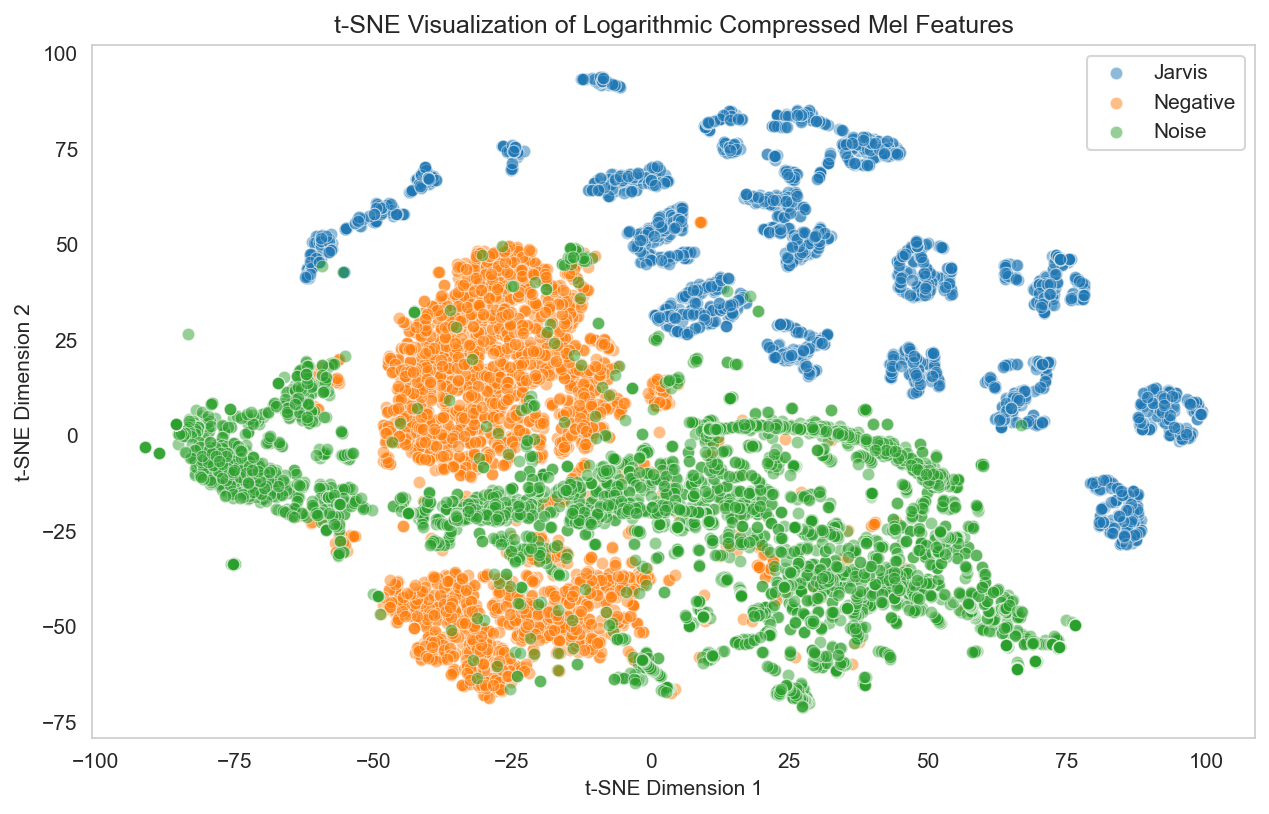

In [9]:
# Visualize the compressed mel features using t-sne and scatter plot colored by class labels
from sklearn.manifold import TSNE

# Create a t-SNE instance with 2 components for 2D visualization
tsne = TSNE(n_components=2, random_state=42)

# Reshape the mel features to 2D (samples, features) for t-SNE input
mel_features_2d = tsne.fit_transform(mel_features_windows_dB.reshape(mel_features_windows_dB.shape[0], -1))

# Define figure size and style for the plot
plt.figure(figsize=(10, 6), dpi=150)
sns.set_style("whitegrid")

# Plot each class separately for better visualization
for label in np.unique(frames_labels):
    idx = frames_labels == label
    # plot scatter plot using seaborn for better aesthetics
    sns.scatterplot(x=mel_features_2d[idx, 0], y=mel_features_2d[idx, 1], label=label.capitalize(), alpha=0.5)

# Set the title and labels for the plot
plt.title('t-SNE Visualization of Logarithmic Compressed Mel Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid()
plt.show()

## Flatten Mel Features to Create a Dataset
To flatten Mel features into a 1D array per audio sample, you can use Python with **NumPy** on your machine learning pipeline. Typically, a Mel feature extractor outputs a 2D array of shape $(N_{mels}, T)$, where $N_{mels}$ is the number of frequency bands and $T$ is the number of temporal frames. Flattening converts this into a single 1D vector of length $N_{mels}$ times $T$.

In [10]:
# Determine the number of samples, mel bins, and frames from the mel features shape
n_samples, n_mels, n_frames = mel_features_windows_dB.shape

# Flatten the Mel Features dB for use in a machine learning model
flattened_mel_features = mel_features_windows_dB.reshape(n_samples, n_mels * n_frames)

# Print the shape of the flattened mel features
print(f"Flattened mel features shape: {flattened_mel_features.shape}")

Flattened mel features shape: (10125, 3960)


# One-Hot Encoding
One-hot encoding is a process of converting categorical data variables to be provided to machine learning algorithms to improve predictions. One-hot encoding is a method of representing categorical variables as binary vectors. In this notebook, the crop target classes are encoded using one-hot encoding. Each crop label is represented by a binary vector where one bit is hot (set to 1) and all others are cold (set to 0).

### Sample Format of One-Hot Encoded Targets

If you have 3 classes (e.g., `'Jarvis'`, `'Negative'`, `'Noise'`), they would be encoded as follows:
- `'Jarvis'` -> `[1, 0, 0]`
- `'Negative'` -> `[0, 1, 0]`
- `'Noise'` -> `[0, 0, 1]`

This allows the model to process the categorical data without assuming any ordinal relationship between the categories.


In [11]:
# Import OneHotEncoder from sklearn
from sklearn.preprocessing import OneHotEncoder

# Create an instance of OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target labels using OneHotEncoder
y_encoded = encoder.fit_transform(frames_labels.reshape(-1, 1))

# Create column names for one-hot encoded targets (no underscore in column names)
target_labels = encoder.get_feature_names_out([''])

# Use list comprehension with str.removeprefix()
target_labels = [s.removeprefix('_').capitalize() for s in target_labels]

# Convert encoded target to a data frame
y_encoded_df = pd.DataFrame(y_encoded.astype(int), columns=target_labels)

# Display a random samples of the encoded targets data frame
y_encoded_df.sample(10).style.hide(axis='index')

Jarvis,Negative,Noise
0,1,0
0,1,0
0,1,0
1,0,0
1,0,0
0,0,1
0,1,0
1,0,0
1,0,0
0,1,0


# Splitting the Dataset into Training, Testing, and Validation Set
Splitting a dataset is a crucial step in machine learning to evaluate model performance and prevent overfitting. Typically, the data is divided into three sets:
- **Training Set**: Used to train the model.
- **Validation Set**: Used to tune hyperparameters and select the best model.
- **Testing Set**: Used to assess the final model performance.

A common approach is to first split the data into training and testing sets, then further split the training set into training and validation sets. This ensures that the validation and test sets remain unseen during training and hyperparameter tuning.

<img src="https://cdn.imweb.me/upload/S202105076e626e4618b27/0f0c2df8f341c.png" style="width:70%; height:auto;">

In [12]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split data set to training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(flattened_mel_features, 
                                                    y_encoded, 
                                                    test_size=0.20, 
                                                    shuffle=True, 
                                                    random_state=43, 
                                                    stratify=y_encoded)

# Split the training set for validation (20% of training set) and training (80% of training set)
X_null, X_val, y_null, y_val = train_test_split(X_train, 
                                                y_train,
                                                test_size=0.20,
                                                shuffle=True,
                                                random_state=43,
                                                stratify=y_train)

# Create a dataframe that holds the dataset shape (number of samples and features) for training and testing sets
dataset_shape = pd.DataFrame({
    'Dataset': ['Dataset', 'Training Set', 'Testing Set', 'Validation Set'],
    'Samples': [flattened_mel_features.shape[0], X_train.shape[0], X_test.shape[0], X_val.shape[0]],
    'Features': [flattened_mel_features.shape[1], X_train.shape[1], X_test.shape[1], X_val.shape[1]],
    'Target Classes': [y_encoded.shape[1], y_train.shape[1], y_test.shape[1], y_val.shape[1]]
})

# Display the training and test set shapes
dataset_shape.style.hide(axis='index')

Dataset,Samples,Features,Target Classes
Dataset,10125,3960,3
Training Set,8100,3960,3
Testing Set,2025,3960,3
Validation Set,1620,3960,3


In [25]:
from keras.models import Sequential
from keras.layers import Input, Dense

# Create a sequential model with an explicit Input layer
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input Layer with shape equal to the number of features
    Dense(64, activation='relu'),      # First hidden layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),      # Second hidden layer with 32 neurons and ReLU activation
    Dense(16, activation='relu'),      # Third hidden layer with 16 neurons and ReLU activation
    Dense(8, activation='relu'),       # Fourth hidden layer with 8 neurons and ReLU activation
    Dense(y_train.shape[1],            # Output layer with shape equal to the number of target classes
          activation='softmax')        # and softmax activation function for multiclass classification
])

# Compile the model with categorical crossentropy loss and accuracy metric
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with one-hot targets directly
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
)

Epoch 1/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6860 - loss: 0.9434 - val_accuracy: 0.7099 - val_loss: 0.6295
Epoch 2/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8467 - loss: 0.4528 - val_accuracy: 0.8457 - val_loss: 0.4447
Epoch 3/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8720 - loss: 0.3940 - val_accuracy: 0.8420 - val_loss: 0.4733
Epoch 4/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8869 - loss: 0.3450 - val_accuracy: 0.8969 - val_loss: 0.2687
Epoch 5/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - loss: 0.2766 - val_accuracy: 0.9006 - val_loss: 0.2799
Epoch 6/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9095 - loss: 0.2667 - val_accuracy: 0.9086 - val_loss: 0.2976
Epoch 7/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9162 - loss: 0.2457 - val_accuracy: 0.8444 - val_loss: 0.4421
Epoch 8/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9230 - loss: 0.2276 - val_accu

# Visualization of Keras Neural Network Training Process
Visualize Keras loss curves by plotting the `history.history` dictionary returned by `model.fit()` using Matplotlib. Key metrics to plot include training loss (`'loss'`) and validation loss (`'val_loss'`) against epochs to identify overfitting or underfitting. This provides a clear visualization of training progress and performance. After training a Keras model, use the history object to plot the loss. 

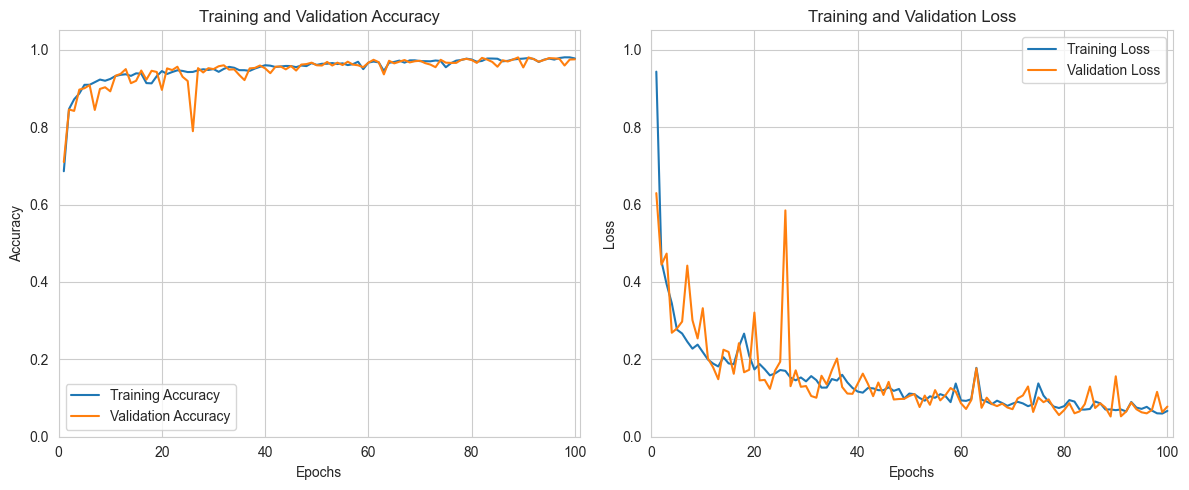

In [26]:
import matplotlib.pyplot as plt

# Compute for the training and validation accuracy from the training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Compute for the training and validation loss from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# return epochs range for plotting
epochs_range = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xlim(0, epochs_range[-1] + 1)
plt.ylim(0, 1.05)
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 1.05)
plt.legend()
plt.xlim(0, epochs_range[-1] + 1)
plt.tight_layout()
plt.show()

In [27]:
# Evaluate the model on the training and test sets
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

# Create a dataframe to display the evaluation results
evaluation_results = pd.DataFrame({
    'Dataset': ['Training Set', 'Validation Set'],
    'Loss': [f'{train_loss:.4f}', f'{val_loss:.4f}'],
    'Accuracy': [f'{train_accuracy * 100.00:.2f}%', f'{val_accuracy * 100.00:.2f}%']
})

# Display the evaluation results
evaluation_results.style.hide(axis='index')

Dataset,Loss,Accuracy
Training Set,0.0705,97.58%
Validation Set,0.0779,97.53%


# Performance of the Classifier Model
Keras classifier performance is evaluated by compiling models with metrics like accuracy, training with `model.fit()`, and evaluating on test data.

In [28]:
# Print the performance metrics such as accuracy, precision, recall, and F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Perform prediction on the test set
predictions = model.predict(X_test)

# Convert one-hot encoded true labels and predicted probabilities to class indices
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(predictions)

# Create a dataframe to display the true labels and predicted labels
results_df = pd.DataFrame({
    'True Label': y_test_labels.flatten(),  
    'Predicted Label': y_pred_labels.flatten()
})

# Display 10 random samples of the true labels and predicted labels
results_df.sample(10).style.hide(axis='index')

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


True Label,Predicted Label
negative,negative
noise,noise
negative,negative
noise,noise
negative,negative
noise,noise
jarvis,jarvis
jarvis,jarvis
negative,negative
jarvis,jarvis


In [29]:
# Create a dataframe for the model performance metrics
performance_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f'{accuracy_score(y_test_labels, y_pred_labels) * 100.00:.2f}%',
              f'{precision_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{recall_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{f1_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%']
})

# Display the performance metrics
performance_metrics.style.hide(axis='index')

Metric,Score
Accuracy,97.38%
Precision,97.44%
Recall,97.38%
F1 Score,97.39%


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


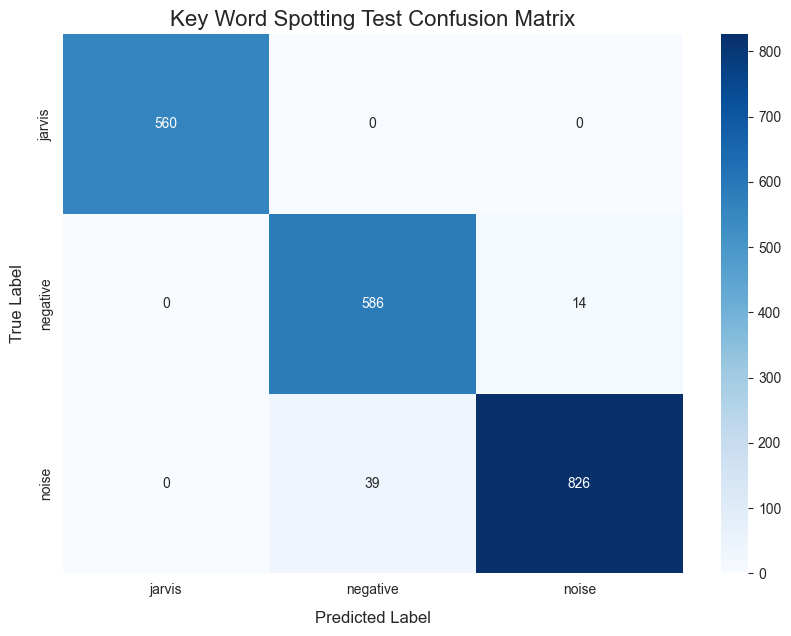

In [30]:
# Confusion Matrix and Classification Report
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Use test set for unbiased evaluation
y_test_true = encoder.inverse_transform(y_test).ravel()
y_test_pred = encoder.inverse_transform(model.predict(X_test)).ravel()

# Use encoder-native class order to avoid label name mismatches
class_labels = encoder.categories_[0]
cm_test = confusion_matrix(y_test_true, y_test_pred, labels=class_labels)

# Plot confusion matrix for the test set
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_labels, yticklabels=class_labels)
plt.title('Key Word Spotting Test Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.show()